In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [4]:
df = pd.read_csv(r"C:\Users\HP\Documents\project works\Projects\Predictive Health Risk Classification\dataset\health_dataset.csv")

print("Shape:", df.shape)

display(df.head())

Shape: (9549, 23)


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [5]:
print(df.columns)

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [7]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [8]:
missing = df.isnull().sum()

print(missing)

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64


In [9]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(
    missing_percentage.sort_values(
        ascending=False
    )
)

Age                      0.0
Alcohol                  0.0
Blood_Group_B            0.0
Blood_Group_AB           0.0
Diet_Type__Vegetarian    0.0
Diet_Type__Vegan         0.0
Allergies                0.0
MedicalHistory           0.0
PhysicalActivity         0.0
MentalHealth             0.0
Diet                     0.0
Smoking                  0.0
BMI                      0.0
Target                   0.0
Stress_Level             0.0
Water_Intake             0.0
Exercise_Hours           0.0
Sleep_Hours              0.0
Heart_Rate               0.0
Glucose_Level            0.0
Cholesterol              0.0
Blood_Pressure           0.0
Blood_Group_O            0.0
dtype: float64


In [10]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [11]:
print(df.dtypes)

Age                      float64
BMI                      float64
Blood_Pressure           float64
Cholesterol              float64
Glucose_Level            float64
Heart_Rate               float64
Sleep_Hours              float64
Exercise_Hours           float64
Water_Intake             float64
Stress_Level             float64
Target                     int64
Smoking                    int64
Alcohol                    int64
Diet                       int64
MentalHealth               int64
PhysicalActivity           int64
MedicalHistory             int64
Allergies                  int64
Diet_Type__Vegan            bool
Diet_Type__Vegetarian       bool
Blood_Group_AB              bool
Blood_Group_B               bool
Blood_Group_O               bool
dtype: object


In [12]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print(categorical_columns)

Index([], dtype='object')


In [13]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies'],
      dtype='object')


In [14]:
bool_columns = df.select_dtypes(include="bool").columns

df[bool_columns] = df[bool_columns].astype(int)

In [15]:
print(df.dtypes)

Age                      float64
BMI                      float64
Blood_Pressure           float64
Cholesterol              float64
Glucose_Level            float64
Heart_Rate               float64
Sleep_Hours              float64
Exercise_Hours           float64
Water_Intake             float64
Stress_Level             float64
Target                     int64
Smoking                    int64
Alcohol                    int64
Diet                       int64
MentalHealth               int64
PhysicalActivity           int64
MedicalHistory             int64
Allergies                  int64
Diet_Type__Vegan           int32
Diet_Type__Vegetarian      int32
Blood_Group_AB             int32
Blood_Group_B              int32
Blood_Group_O              int32
dtype: object


In [16]:
print(df["Target"].value_counts())

Target
1    4979
0    4570
Name: count, dtype: int64


In [17]:
print(
    df["Target"].value_counts(
        normalize=True
    ) * 100
)

Target
1    52.141586
0    47.858414
Name: proportion, dtype: float64


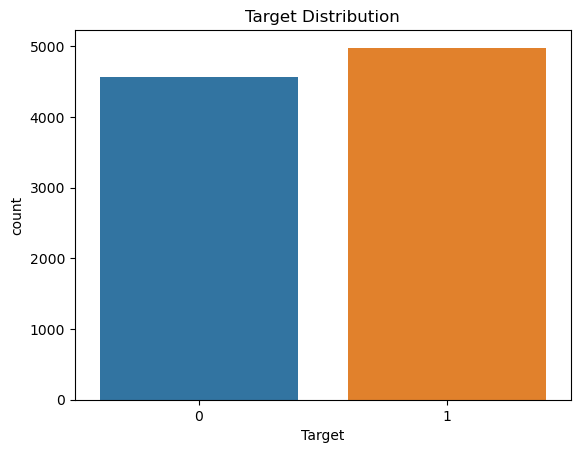

In [18]:
sns.countplot(
    data=df,
    x="Target"
)

plt.title("Target Distribution")
plt.show()

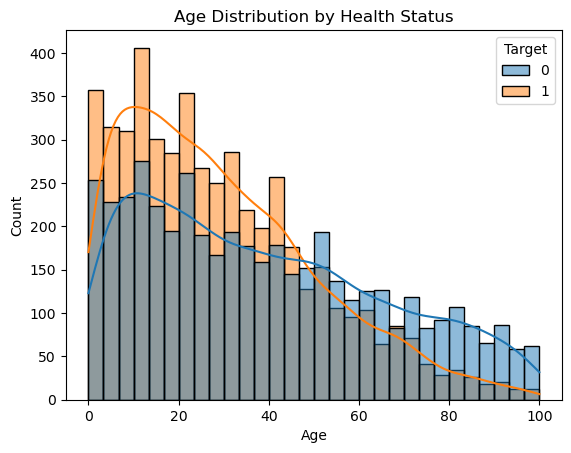

In [19]:
sns.histplot(
    data=df,
    x="Age",
    hue="Target",
    kde=True
)

plt.title("Age Distribution by Health Status")
plt.show()


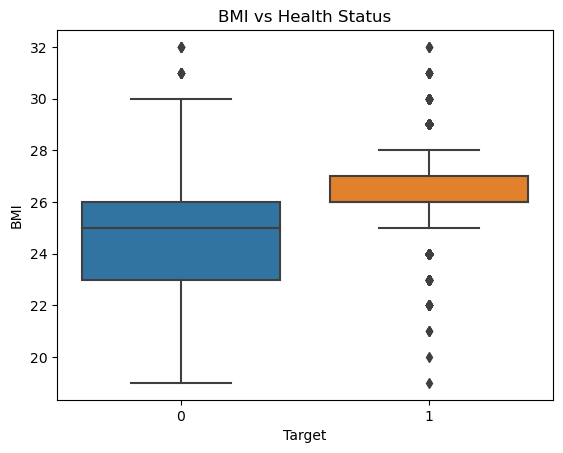

In [20]:
sns.boxplot(
    data=df,
    x="Target",
    y="BMI"
)

plt.title("BMI vs Health Status")
plt.show()

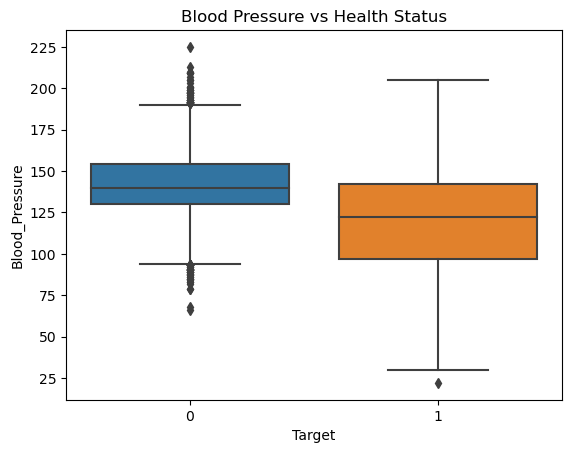

In [21]:
sns.boxplot(
    data=df,
    x="Target",
    y="Blood_Pressure"
)

plt.title(
    "Blood Pressure vs Health Status"
)

plt.show()

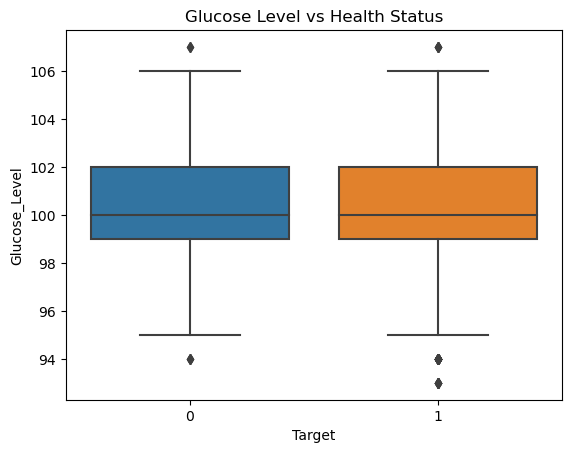

In [22]:
sns.boxplot(
    data=df,
    x="Target",
    y="Glucose_Level"
)

plt.title(
    "Glucose Level vs Health Status"
)

plt.show()

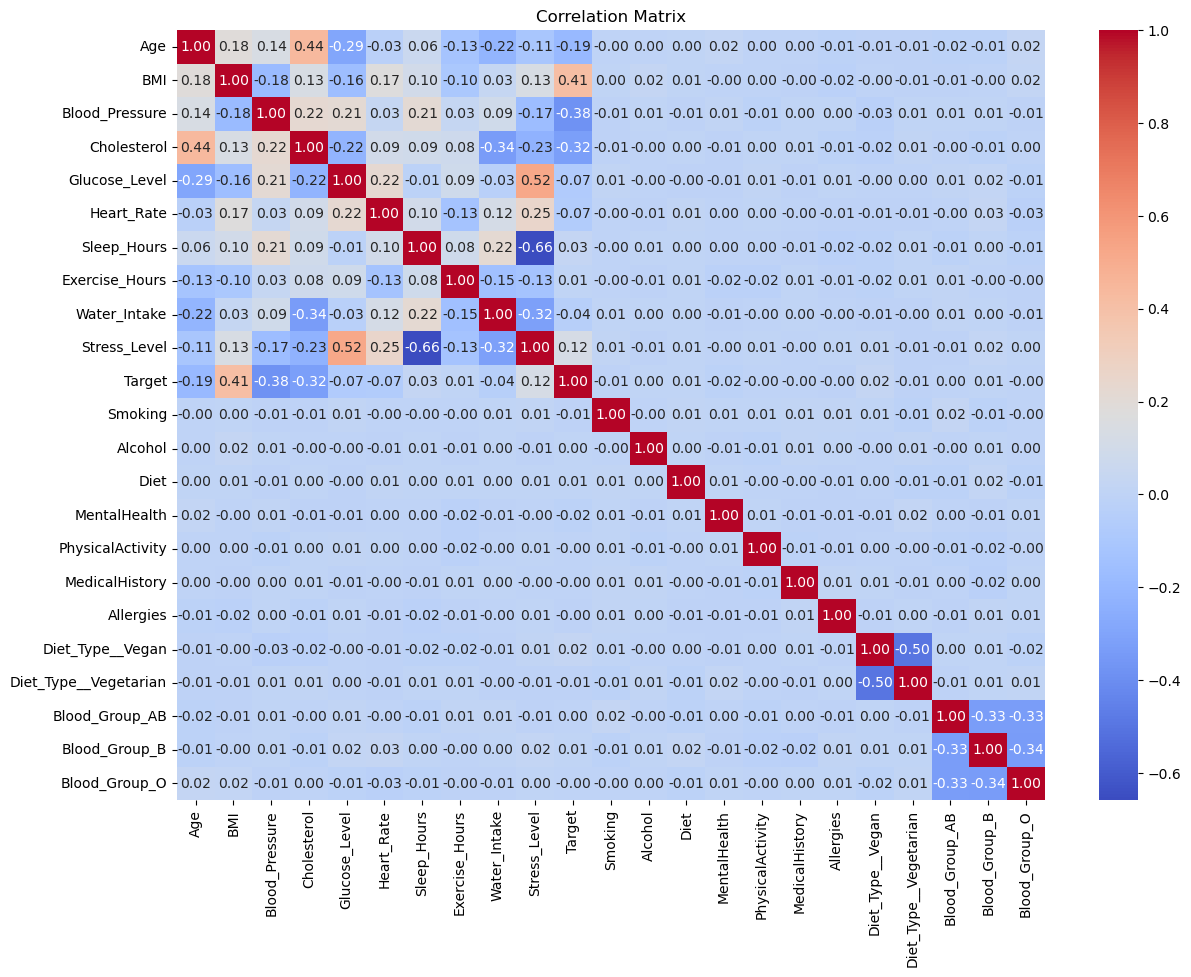

In [23]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

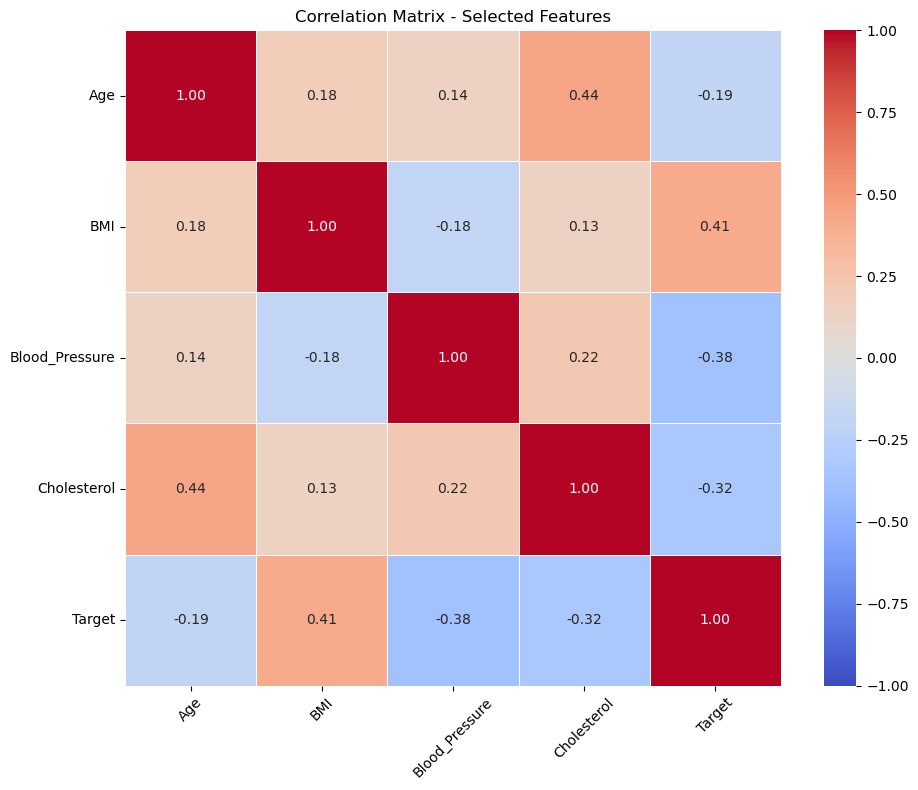

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Target"
]

# Make sure selected columns are numeric
corr = df[cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix - Selected Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
cols = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Target"
]

corr = df[cols].corr()

print(corr)

                     Age       BMI  Blood_Pressure  Cholesterol    Target
Age             1.000000  0.184184        0.135372     0.437928 -0.190743
BMI             0.184184  1.000000       -0.184409     0.133500  0.413972
Blood_Pressure  0.135372 -0.184409        1.000000     0.223215 -0.380279
Cholesterol     0.437928  0.133500        0.223215     1.000000 -0.324361
Target         -0.190743  0.413972       -0.380279    -0.324361  1.000000


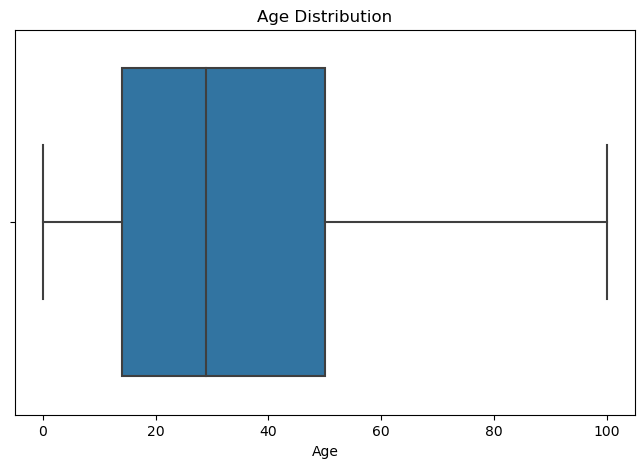

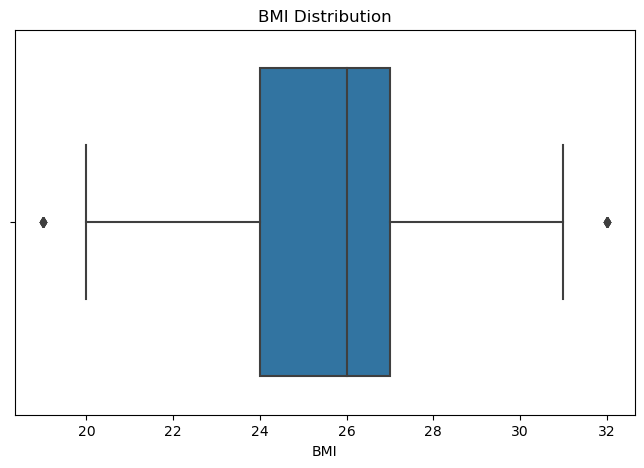

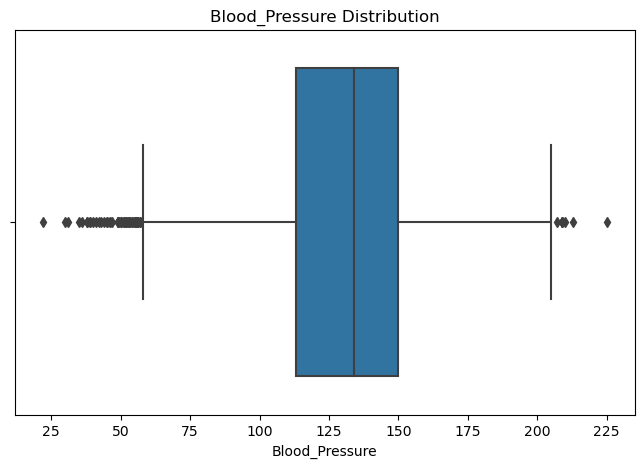

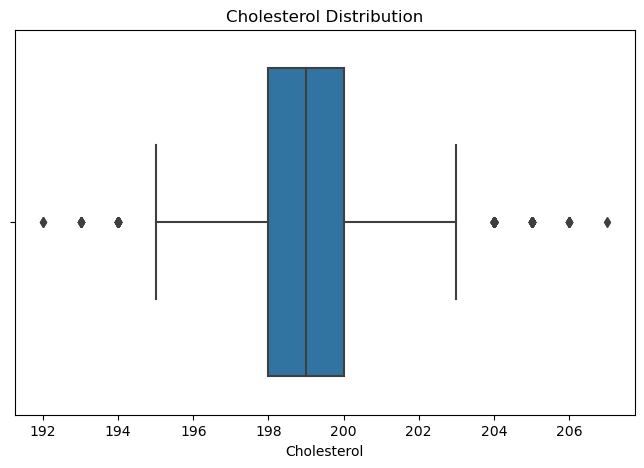

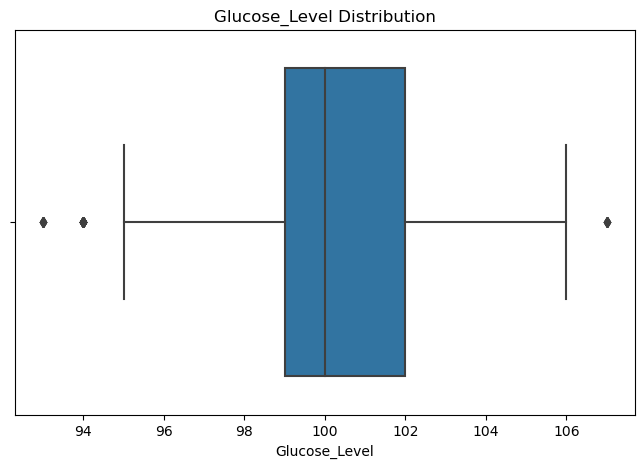

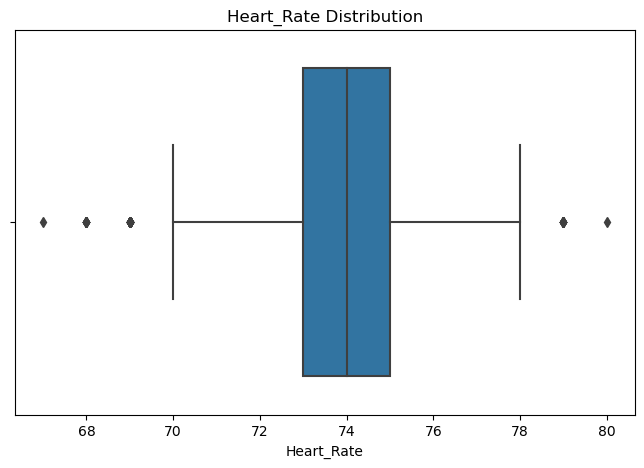

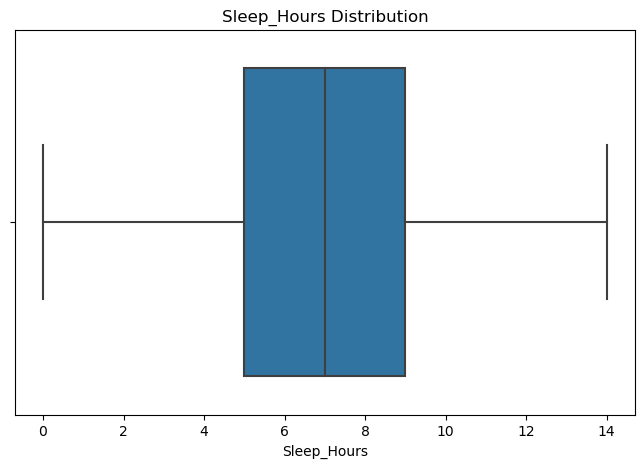

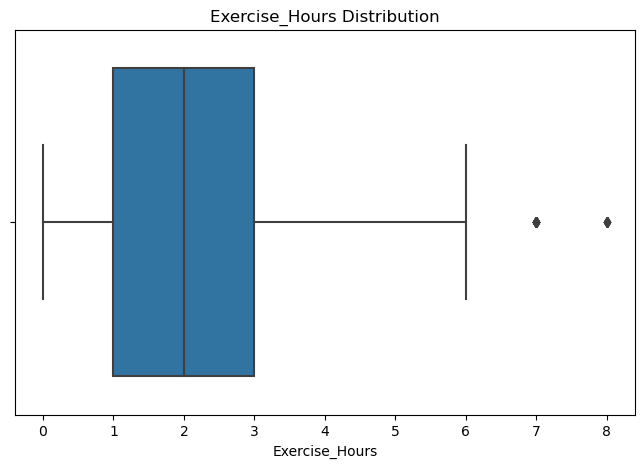

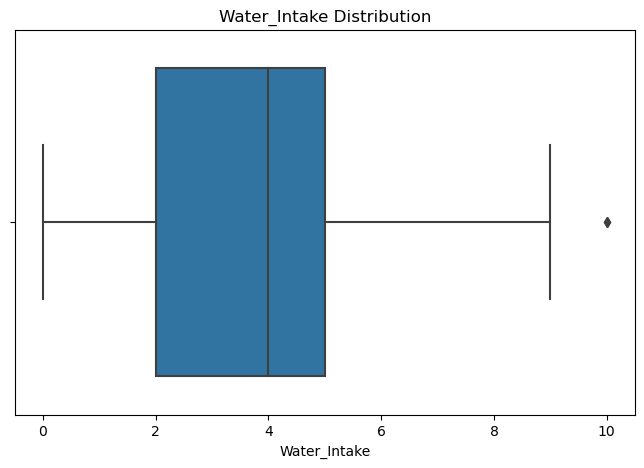

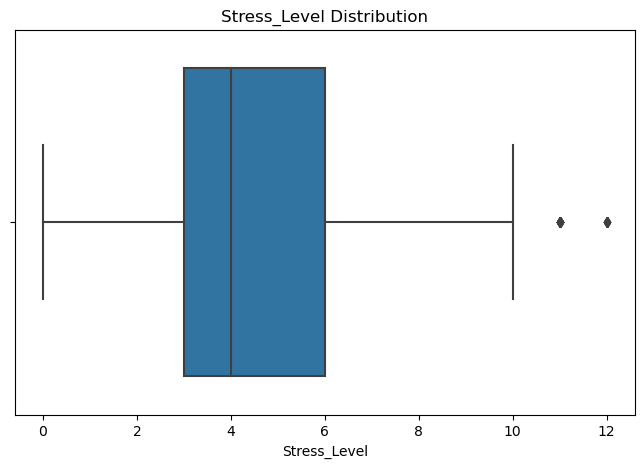

In [26]:
features = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Glucose_Level",
    "Heart_Rate",
    "Sleep_Hours",
    "Exercise_Hours",
    "Water_Intake",
    "Stress_Level"
]

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(x=df[feature])

    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)

    plt.show()

In [27]:
print(df["Blood_Pressure"].describe())

count    9549.000000
mean      130.382658
std        27.878476
min        22.000000
25%       113.000000
50%       134.000000
75%       150.000000
max       225.000000
Name: Blood_Pressure, dtype: float64


In [28]:
print(df.describe())

               Age          BMI  Blood_Pressure  Cholesterol  Glucose_Level  \
count  9549.000000  9549.000000     9549.000000  9549.000000    9549.000000   
mean     33.806786    25.660697      130.382658   199.091528     100.225678   
std      24.566473     1.942369       27.878476     1.969234       2.157999   
min       0.000000    19.000000       22.000000   192.000000      93.000000   
25%      14.000000    24.000000      113.000000   198.000000      99.000000   
50%      29.000000    26.000000      134.000000   199.000000     100.000000   
75%      50.000000    27.000000      150.000000   200.000000     102.000000   
max     100.000000    32.000000      225.000000   207.000000     107.000000   

        Heart_Rate  Sleep_Hours  Exercise_Hours  Water_Intake  Stress_Level  \
count  9549.000000  9549.000000     9549.000000   9549.000000   9549.000000   
mean     73.613782     6.951409        1.892345      3.580899      4.382134   
std       1.681538     2.352152        1.378714    

In [29]:
print("Zero Sleep Hours:", (df["Sleep_Hours"] == 0).sum())

Zero Sleep Hours: 22


In [30]:
print(df["Sleep_Hours"].describe())

print("Minimum:", df["Sleep_Hours"].min())
print("Maximum:", df["Sleep_Hours"].max())

count    9549.000000
mean        6.951409
std         2.352152
min         0.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        14.000000
Name: Sleep_Hours, dtype: float64
Minimum: 0.0
Maximum: 14.0


In [31]:
print(df[
    (df["Sleep_Hours"] < 0) |
    (df["Sleep_Hours"] > 24)
])

Empty DataFrame
Columns: [Age, BMI, Blood_Pressure, Cholesterol, Glucose_Level, Heart_Rate, Sleep_Hours, Exercise_Hours, Water_Intake, Stress_Level, Target, Smoking, Alcohol, Diet, MentalHealth, PhysicalActivity, MedicalHistory, Allergies, Diet_Type__Vegan, Diet_Type__Vegetarian, Blood_Group_AB, Blood_Group_B, Blood_Group_O]
Index: []

[0 rows x 23 columns]


In [32]:
df["Sleep_Hours"] = df["Sleep_Hours"].replace(0, np.nan)

In [33]:
print(df["Sleep_Hours"].isnull().sum())

22


In [34]:
df["Sleep_Hours"] = df["Sleep_Hours"].fillna(
    df["Sleep_Hours"].median()
)

In [35]:
count = (df["Sleep_Hours"] < 2).sum()

print("People with less than 2 hours of sleep:", count)

People with less than 2 hours of sleep: 80


In [36]:
percentage = (df["Sleep_Hours"] < 2).mean() * 100

print(f"Percentage with less than 2 hours of sleep: {percentage:.2f}%")

Percentage with less than 2 hours of sleep: 0.84%


In [37]:
print("Sleep < 2 hours:", (df["Sleep_Hours"] < 2).sum())
print("Sleep = 0 hours:", (df["Sleep_Hours"] == 0).sum())

Sleep < 2 hours: 80
Sleep = 0 hours: 0


In [38]:
print(df.describe())

               Age          BMI  Blood_Pressure  Cholesterol  Glucose_Level  \
count  9549.000000  9549.000000     9549.000000  9549.000000    9549.000000   
mean     33.806786    25.660697      130.382658   199.091528     100.225678   
std      24.566473     1.942369       27.878476     1.969234       2.157999   
min       0.000000    19.000000       22.000000   192.000000      93.000000   
25%      14.000000    24.000000      113.000000   198.000000      99.000000   
50%      29.000000    26.000000      134.000000   199.000000     100.000000   
75%      50.000000    27.000000      150.000000   200.000000     102.000000   
max     100.000000    32.000000      225.000000   207.000000     107.000000   

        Heart_Rate  Sleep_Hours  Exercise_Hours  Water_Intake  Stress_Level  \
count  9549.000000  9549.000000     9549.000000   9549.000000   9549.000000   
mean     73.613782     6.967536        1.892345      3.580899      4.382134   
std       1.681538     2.328309        1.378714    

In [39]:
print(df["Age"].describe())

count    9549.000000
mean       33.806786
std        24.566473
min         0.000000
25%        14.000000
50%        29.000000
75%        50.000000
max       100.000000
Name: Age, dtype: float64


In [40]:
print("Age = 0:", (df["Age"] == 0).sum())

Age = 0: 96


In [41]:
print("Age 0-10:", ((df["Age"] >= 0) & (df["Age"] <= 10)).sum())
print("Age 11-20:", ((df["Age"] >= 11) & (df["Age"] <= 20)).sum())
print("Age 21-40:", ((df["Age"] >= 21) & (df["Age"] <= 40)).sum())
print("Age 41-60:", ((df["Age"] >= 41) & (df["Age"] <= 60)).sum())
print("Age 61-80:", ((df["Age"] >= 61) & (df["Age"] <= 80)).sum())
print("Age 81-100:", ((df["Age"] >= 81) & (df["Age"] <= 100)).sum())

Age 0-10: 1860
Age 11-20: 1682
Age 21-40: 2666
Age 41-60: 1784
Age 61-80: 1002
Age 81-100: 555


In [42]:
print(df["Age"].value_counts().sort_index())

Age
0.0       96
1.0      159
2.0      174
3.0      181
4.0      167
        ... 
96.0      28
97.0      17
98.0      18
99.0      20
100.0     19
Name: count, Length: 101, dtype: int64


In [43]:
X = df.drop(
    "Target",
    axis=1
)

y = df["Target"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
numeric_features = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Glucose_Level",
    "Heart_Rate",
    "Sleep_Hours",
    "Exercise_Hours",
    "Water_Intake",
    "Stress_Level"
]

In [46]:
categorical_features = [
    "Smoking",
    "Alcohol",
    "Diet",
    "MentalHealth",
    "PhysicalActivity",
    "MedicalHistory",
    "Allergies"
]

In [47]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [48]:
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [49]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [50]:
StandardScaler()

StandardScaler()

In [51]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [52]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI',
                                                   'Blood_Pressure',
                                                   'Cholesterol',
                                                   'Glucose_Level',
                                                   'Heart_Rate', 'Sleep_Hours',
                                                   'Exercise_Hours',
                                                   'Water_Intake',
                                                   'Stress_Level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Smoking', 'Alcohol', 'Diet',
                                                   'MentalHealth',
                                                   'PhysicalActivity',
                                                   'MedicalHistory',
                                                   'Allergies'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [53]:
lr_pred = logistic_pipeline.predict(
    X_test
)

In [54]:
lr_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [55]:
decision_tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [56]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI',
                                                   'Blood_Pressure',
                                                   'Cholesterol',
                                                   'Glucose_Level',
                                                   'Heart_Rate', 'Sleep_Hours',
                                                   'Exercise_Hours',
                                                   'Water_Intake',
                                                   'Stress_Level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Smoking', 'Alcohol', 'Diet',
                                                   'MentalHealth',
                                                   'PhysicalActivity',
                                                   'MedicalHistory',
                                                   'Allergies'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [57]:
dt_pred = decision_tree_pipeline.predict(
    X_test
)

In [58]:
random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [59]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI',
                                                   'Blood_Pressure',
                                                   'Cholesterol',
                                                   'Glucose_Level',
                                                   'Heart_Rate', 'Sleep_Hours',
                                                   'Exercise_Hours',
                                                   'Water_Intake',
                                                   'Stress_Level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Smoking', 'Alcohol', 'Diet',
                                                   'MentalHealth',
                                                   'PhysicalActivity',
                                                   'MedicalHistory',
                                                   'Allergies'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [60]:
rf_pred = random_forest_pipeline.predict(
    X_test
)

rf_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

In [61]:
gradient_boosting_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

In [62]:
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

gb_pred = gradient_boosting_pipeline.predict(
    X_test
)

gb_prob = gradient_boosting_pipeline.predict_proba(
    X_test
)[:, 1]

In [63]:
def evaluate_model(
    name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1": f1_score(
            y_true,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [64]:
lr_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [65]:
dt_prob = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

In [66]:
rf_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

In [67]:
gb_prob = gradient_boosting_pipeline.predict_proba(
    X_test
)[:, 1]

In [68]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred,
        dt_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_prob
    )
)

In [69]:
results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "F1",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
2        Random Forest  0.931414   0.918683  0.952811  0.935436  0.982001
3    Gradient Boosting  0.915183   0.901734  0.939759  0.920354  0.971778
1        Decision Tree  0.891099   0.889328  0.903614  0.896414  0.890538
0  Logistic Regression  0.814136   0.818272  0.827309  0.822766  0.887387


# Cross Validation

In [70]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

CV F1 Scores: [0.94117647 0.93092719 0.94313968 0.93498452 0.93875   ]
Mean CV F1: 0.9377955725711926
Std CV F1: 0.0043812673753273424


In [71]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [72]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'BMI',
                                                                          'Blood_Pressure',
                                                                          'Cholesterol',
                                                                          'Glucose_Level',
                                                                          'Heart_Rate',
                                                                          'Sleep_Hours',
                                                                          'Exercise_Hours',
                                                                          'Water_Intake',
                                                                          'Stress_Level']),
                                                                        ('cat',
                                                                         Pipeline(steps=[(...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Smoking',
                                                                          'Alcohol',
                                                                          'Diet',
                                                                          'MentalHealth',
                                                                          'PhysicalActivity',
                                                                          'MedicalHistory',
                                                                          'Allergies'])])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='f1')

In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best CV F1:
0.9365588920222011


In [74]:
best_model = grid_search.best_estimator_

In [75]:
final_pred = best_model.predict(X_test)

final_prob = best_model.predict_proba(X_test)[:, 1]

In [76]:
print(
    "Accuracy:",
    accuracy_score(y_test, final_pred)
)

print(
    "Precision:",
    precision_score(y_test, final_pred)
)

print(
    "Recall:",
    recall_score(y_test, final_pred)
)

print(
    "F1:",
    f1_score(y_test, final_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, final_prob)
)

Accuracy: 0.9293193717277487
Precision: 0.9167473378509197
Recall: 0.9508032128514057
F1: 0.9334647609659932
ROC-AUC: 0.9818277486312866


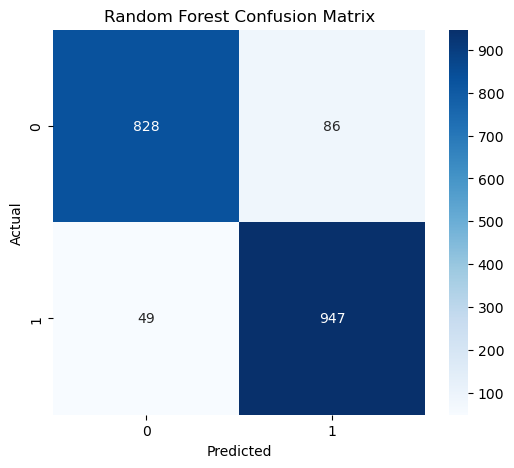

In [77]:
cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
final_pred = best_model.predict(X_test)

# Get probability of positive class
final_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, final_pred)
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
roc_auc = roc_auc_score(y_test, final_prob)

print("Final Model Performance")
print("-----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Final Model Performance
-----------------------
Accuracy : 0.9293193717277487
Precision: 0.9167473378509197
Recall   : 0.9508032128514057
F1 Score : 0.9334647609659932
ROC-AUC  : 0.9818277486312866


In [79]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_pred,
    target_names=["Healthy", "Unhealthy"]
))

              precision    recall  f1-score   support

     Healthy       0.94      0.91      0.92       914
   Unhealthy       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910



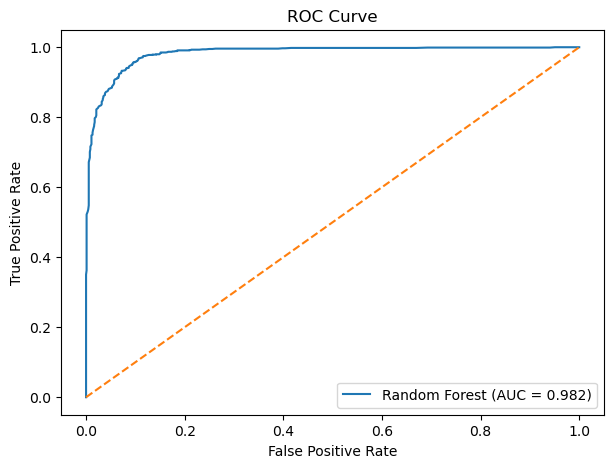

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_prob
)

auc_score = roc_auc_score(
    y_test,
    final_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the trained Random Forest
rf_model = best_model.named_steps["model"]

# Get the fitted preprocessor
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Random Forest feature importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from highest to lowest
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(15))

                    Feature  Importance
1                  num__BMI    0.209271
2       num__Blood_Pressure    0.150122
3          num__Cholesterol    0.105761
9         num__Stress_Level    0.080526
4        num__Glucose_Level    0.069908
0                  num__Age    0.069819
6          num__Sleep_Hours    0.067965
5           num__Heart_Rate    0.048439
8         num__Water_Intake    0.047986
7       num__Exercise_Hours    0.026887
30         cat__Allergies_2    0.006120
17              cat__Diet_1    0.006080
28         cat__Allergies_0    0.006059
12           cat__Smoking_2    0.006049
24  cat__PhysicalActivity_2    0.006046


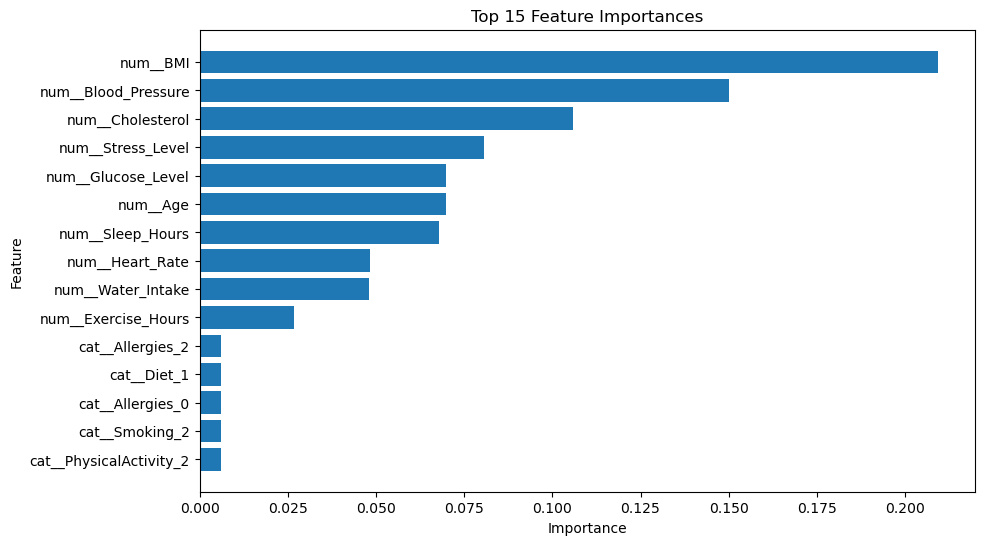

In [82]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

In [84]:
import joblib

joblib.dump(
    best_model,
    "health_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
